# Splines and GAMs — Moving Beyond Linearity

> Inspired by **ISLR Ch. 7** ([book club notes](https://r4ds.github.io/bookclub-islr/moving-beyond-linearity.html)).

Five non-linear fits to a single 1-D curve, then a multivariate **GAM**.

| Method | Idea |
|---|---|
| Polynomial regression | $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots$ |
| Step functions | piecewise constants between knots |
| Regression splines | piecewise polynomials with continuity at knots |
| Smoothing splines | minimise $\text{RSS} + \lambda \int f''(x)^2 dx$ |
| GAM | $y = \beta_0 + \sum_j f_j(x_j)$ — additive non-linear in each $x_j$ |


## The picture — basis functions stacked together = a flexible smooth fit

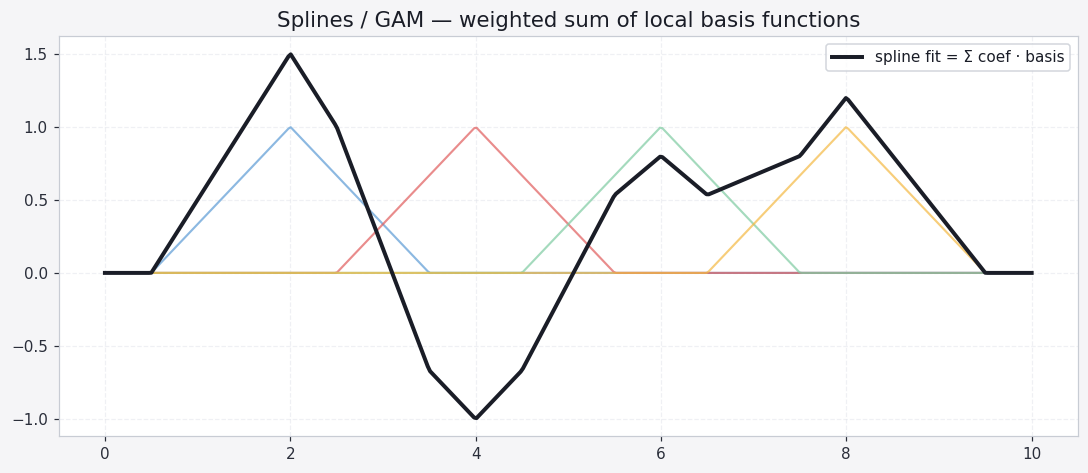

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
x = np.linspace(0, 10, 400)
knots = [2, 4, 6, 8]
fig, ax = plt.subplots(figsize=(10, 4.4))
bases = []
for k, c in zip(knots, [P[0], P[1], P[3], P[2]]):
    b = np.maximum(0, 1 - np.abs(x-k)/1.5)
    bases.append(b); ax.plot(x, b, color=c, lw=1.4, alpha=0.7)
coef = [1.5, -1.0, 0.8, 1.2]
y = sum(c*b for c,b in zip(coef, bases))
ax.plot(x, y, color='#1a1d27', lw=2.6, label='spline fit = Σ coef · basis')
ax.set_title('Splines / GAM — weighted sum of local basis functions')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from scipy.interpolate import BSpline, UnivariateSpline
from pygam import LinearGAM, s

rng = np.random.RandomState(0)
def f_true(x): return np.sin(2*x) + 0.3*x
x = rng.uniform(0, 5, 80); y = f_true(x) + 0.4*rng.randn(80)
xs = np.linspace(0, 5, 400)
print('1-D dataset: n=80, x in [0,5]')


1-D dataset: n=80, x in [0,5]


---
## Five 1-D fits side-by-side


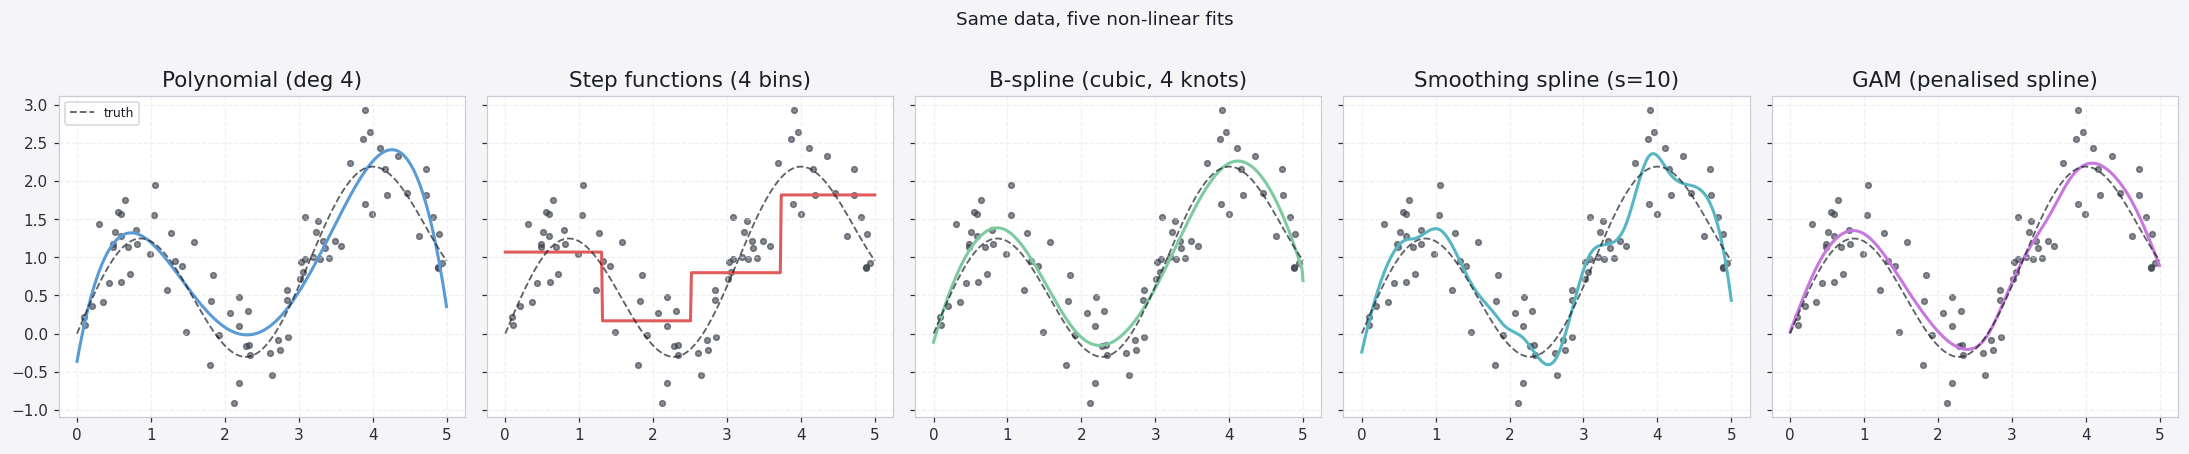

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

# 1. Polynomial degree 4
poly = make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(x[:,None], y)
axes[0].set_title('Polynomial (deg 4)')
axes[0].plot(xs, poly.predict(xs[:,None]), color=PALETTE[0], lw=2)

# 2. Step functions (4 bins)
disc = KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='uniform')
step = make_pipeline(disc, LinearRegression()).fit(x[:,None], y)
axes[1].set_title('Step functions (4 bins)')
axes[1].plot(xs, step.predict(xs[:,None]), color=PALETTE[1], lw=2)

# 3. B-spline regression (cubic, 4 internal knots)
from numpy.polynomial import polynomial as P
def bspline_basis(x, knots, k=3):
    t = np.r_[[knots[0]]*k, knots, [knots[-1]]*k]
    n_basis = len(t) - k - 1
    return np.column_stack([BSpline.basis_element(t[i:i+k+2])(x) for i in range(n_basis)])
knots = np.linspace(0, 5, 6)
B_tr  = bspline_basis(x, knots)
B_te  = bspline_basis(xs, knots)
beta, *_ = np.linalg.lstsq(B_tr, y, rcond=None)
axes[2].set_title('B-spline (cubic, 4 knots)')
axes[2].plot(xs, B_te @ beta, color=PALETTE[3], lw=2)

# 4. Smoothing spline (auto-smoothness)
sm = UnivariateSpline(np.sort(x), y[np.argsort(x)], s=10)
axes[3].set_title('Smoothing spline (s=10)')
axes[3].plot(xs, sm(xs), color=PALETTE[4], lw=2)

# 5. GAM
gam = LinearGAM(s(0)).fit(x[:,None], y)
axes[4].set_title('GAM (penalised spline)')
axes[4].plot(xs, gam.predict(xs[:,None]), color=PALETTE[5], lw=2)

for ax in axes:
    ax.scatter(x, y, s=14, color='#3a3e4a', alpha=0.6)
    ax.plot(xs, f_true(xs), color='#1a1d27', lw=1.2, ls='--', alpha=0.7, label='truth')
    ax.grid(True)
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('Same data, five non-linear fits', y=1.02)
fig.tight_layout(); plt.show()


---
## Multivariate GAM with partial-dependence plots

A GAM models $y = \beta_0 + \sum_j f_j(x_j)$ — each component is a smooth, but *additive*. The win: every $f_j$ can be plotted to show its *individual* contribution.


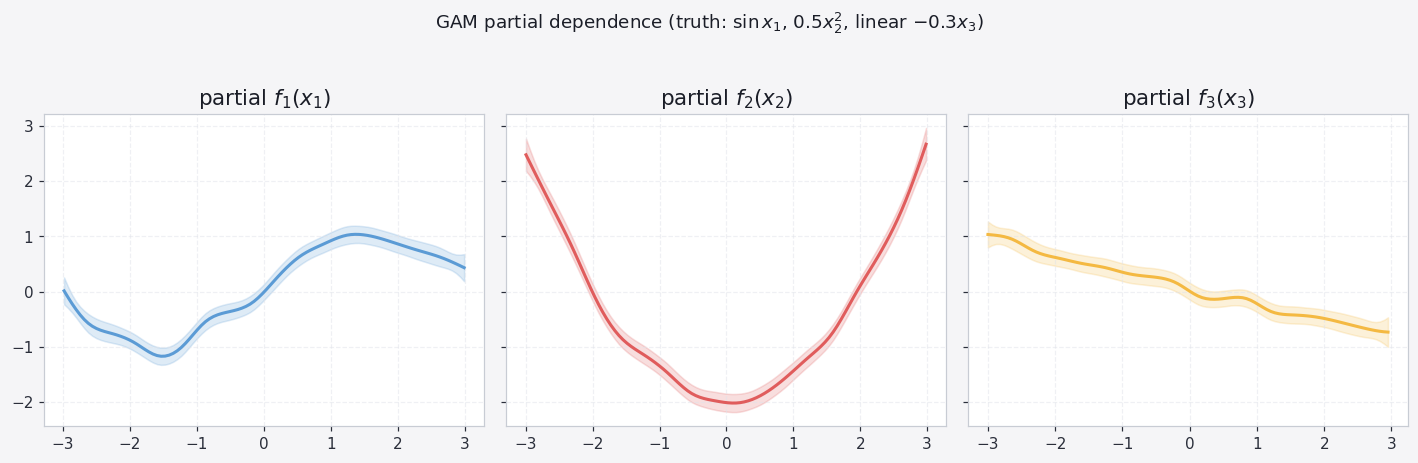

Pseudo-R² = 0.9173267202220996


In [4]:
rng2 = np.random.RandomState(1)
n = 400
X = rng2.uniform(-3, 3, (n, 3))
y2 = np.sin(X[:,0]) + 0.5*X[:,1]**2 - 0.3*X[:,2] + 0.5*rng2.randn(n)

gam2 = LinearGAM(s(0) + s(1) + s(2)).fit(X, y2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for i, ax in enumerate(axes):
    XX = gam2.generate_X_grid(term=i)
    pdep, ci = gam2.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep, color=PALETTE[i], lw=2)
    ax.fill_between(XX[:, i], ci[:,0], ci[:,1], color=PALETTE[i], alpha=0.2)
    ax.set_title(f'partial $f_{i+1}(x_{i+1})$')
    ax.grid(True)
fig.suptitle('GAM partial dependence (truth: $\\sin x_1$, $0.5 x_2^2$, linear $-0.3 x_3$)', y=1.04)
fig.tight_layout(); plt.show()
print('Pseudo-R² =', gam2.statistics_['pseudo_r2']['explained_deviance'])


---
## What we just saw

- All five 1-D methods recover the underlying curve; **regression splines** are the most flexible without overshooting boundary regions.
- The **GAM** approach extends naturally to many predictors and is **interpretable** — each $f_j$ is a curve you can plot, like a non-linear coefficient.
- A GAM is a great middle ground between **linear regression** (interpretable but rigid) and **trees / boosting** (flexible but opaque).

> Lesson: when the truth is non-linear *but additive*, GAMs deliver flexible accuracy with linear-model interpretability.
